# 📘 Supervised Learning — Regression (Complete Revision Notes)

This notebook is a **self-contained revision guide** for every major regression technique in supervised learning.
Each section has a short theory note (why we use it) followed by working code.

**Dataset used:** `tips` from seaborn (predicting `total_bill`), plus we engineer it a bit to make it more interesting.


In [1]:
# If any of these are missing, uncomment and run:
# !pip install xgboost lightgbm scikit-learn seaborn pandas numpy statsmodels --quiet


## 1. Imports
We import everything up front so all tools are available throughout the notebook.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import RFE

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("xgboost not installed -> pip install xgboost")

try:
    from lightgbm import LGBMRegressor
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("lightgbm not installed -> pip install lightgbm")

sns.set_style("whitegrid")


## 2. Load Dataset
We use the built-in seaborn `tips` dataset. Goal: predict `total_bill` from the other features.
This is a nice small dataset with a mix of numeric and categorical columns, perfect for practicing
encoding + scaling + regression end to end.

In [3]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 3. Exploratory Data Analysis (EDA)
**Why:** Before modeling, we must understand the data — its shape, types, missing values, distributions,
and relationships between variables. This guides our feature engineering decisions.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [5]:
df.describe(include='all')

,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


In [6]:
# Check for missing values
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

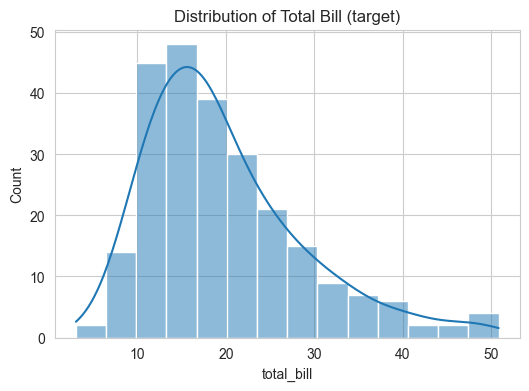

In [7]:
# Distribution of the target variable
plt.figure(figsize=(6,4))
sns.histplot(df['total_bill'], kde=True)
plt.title('Distribution of Total Bill (target)')
plt.show()

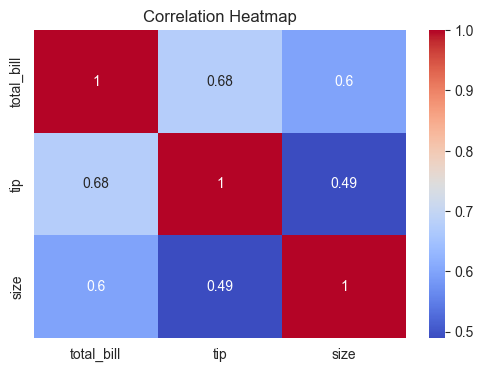

In [8]:
# Numeric correlation heatmap - helps spot multicollinearity early
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

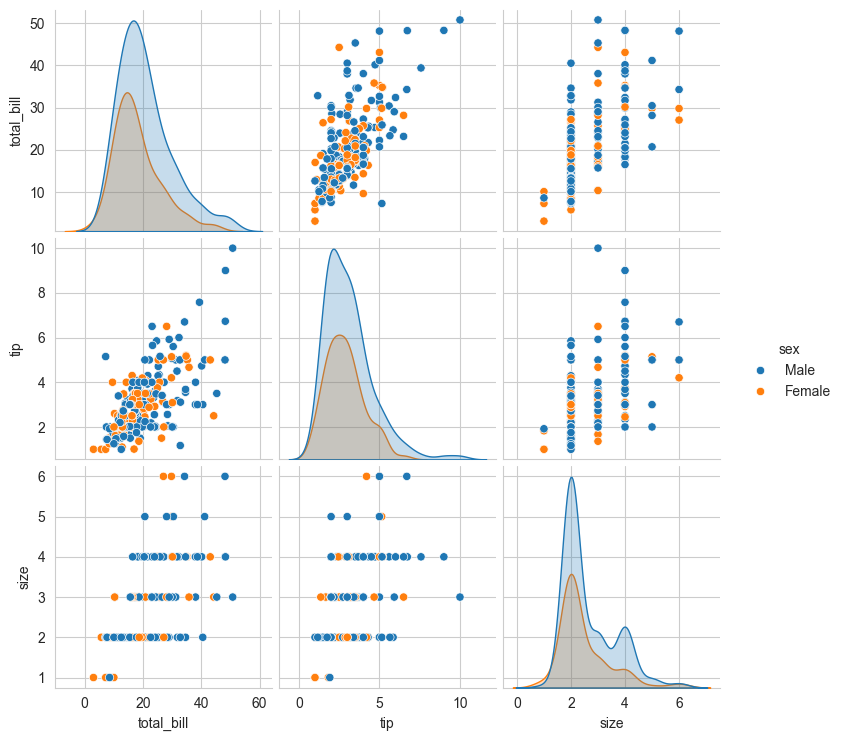

In [9]:
# Pairplot to see relationships and distributions together
sns.pairplot(df, hue='sex')
plt.show()

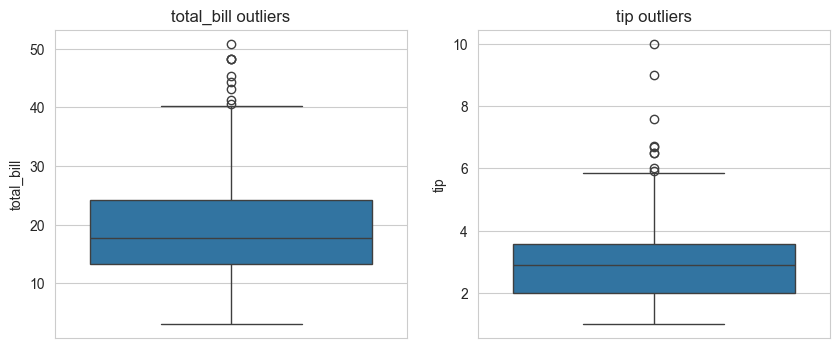

In [10]:
# Boxplots to detect outliers in numeric columns
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.boxplot(y=df['total_bill'], ax=axes[0]); axes[0].set_title('total_bill outliers')
sns.boxplot(y=df['tip'], ax=axes[1]); axes[1].set_title('tip outliers')
plt.show()

## 4. Feature Engineering
**Why:** Raw features are rarely optimal. We create new features, handle missing values, and treat outliers
to help models learn better patterns.

- **Imputation strategies:** mean/median (numeric, robust to few missing), mode (categorical),
  KNNImputer (uses similar rows to estimate missing values — more accurate but slower).
- **Outlier treatment:** here we cap extreme tip values using the IQR rule instead of deleting rows
  (deleting loses data).


In [11]:
# Example imputation demo (this dataset has no missing values, so we simulate one)
demo = df.copy()
demo.loc[0:3, 'total_bill'] = np.nan

# Mean/median imputation
imputer_median = SimpleImputer(strategy='median')
demo['total_bill_median_imputed'] = imputer_median.fit_transform(demo[['total_bill']])

# KNN imputation (uses feature similarity - better when data has patterns)
knn_imputer = KNNImputer(n_neighbors=5)
demo[['tip_knn_imputed']] = knn_imputer.fit_transform(demo[['tip']])

demo[['total_bill','total_bill_median_imputed','tip','tip_knn_imputed']].head()

,total_bill,total_bill_median_imputed,tip,tip_knn_imputed
0,NaN,17.795,1.01,1.01
1,NaN,17.795,1.66,1.66
2,NaN,17.795,3.50,3.50
3,NaN,17.795,3.31,3.31
4,24.59,24.590,3.61,3.61


In [ ]:
# demo = df.copy()

# # Create missing values in tip
# demo.loc[0:3, 'tip'] = np.nan

# knn_imputer = KNNImputer(n_neighbors=5)

# imputed_data = knn_imputer.fit_transform(
#     demo[['total_bill', 'size', 'tip']]
# )

# demo['tip_knn_imputed'] = imputed_data[:, 2]

In [12]:
# Outlier treatment using IQR capping (Winsorization) instead of deleting rows
Q1, Q3 = df['tip'].quantile(0.25), df['tip'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df['tip_capped'] = df['tip'].clip(lower, upper)
print(f"Capped {(df['tip'] != df['tip_capped']).sum()} outlier rows in tip")

Capped 9 outlier rows in tip


In [13]:
# Feature engineering: create a new feature - tip percentage
df['tip_pct'] = df['tip'] / df['total_bill']
df[['total_bill','tip','tip_pct']].head()

,total_bill,tip,tip_pct
0,16.99,1.01,0.059447
1,10.34,1.66,0.160542
2,21.01,3.50,0.166587
3,23.68,3.31,0.139780
4,24.59,3.61,0.146808


## 5. Encoding Categorical Variables
**Why:** ML models need numbers, not text categories.

- **LabelEncoder**: assigns each category an integer. Good for ORDINAL data (has order) or tree models
  (which don't assume numeric distance means anything).
- **OneHotEncoder / pd.get_dummies**: creates a binary column per category. Best for NOMINAL data
  (no order) with LINEAR models, since it avoids implying a false order.
- **OrdinalEncoder**: like LabelEncoder but lets you explicitly define the order (e.g., low < medium < high).


In [14]:
cat_cols = ['sex', 'smoker', 'day', 'time']

# --- OneHotEncoding (best for nominal features + linear models) ---
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.head()

,total_bill,tip,size,tip_capped,tip_pct,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
0,16.99,1.01,2,1.01,0.059447,True,True,False,False,True,True
1,10.34,1.66,3,1.66,0.160542,False,True,False,False,True,True
2,21.01,3.50,3,3.50,0.166587,False,True,False,False,True,True
3,23.68,3.31,2,3.31,0.139780,False,True,False,False,True,True
4,24.59,3.61,4,3.61,0.146808,True,True,False,False,True,True


In [15]:
# --- LabelEncoder demo (useful for tree-based models, or ordinal-like columns) ---
le = LabelEncoder()
demo_label = df.copy()
demo_label['day_label'] = le.fit_transform(demo_label['day'])
demo_label[['day','day_label']].drop_duplicates()

,day,day_label
0,Sun,2
19,Sat,1
77,Thur,3
90,Fri,0


In [16]:
# --- OrdinalEncoder demo (when we know the true order, e.g. Lunch < Dinner is NOT ordinal here,
# but shown for syntax reference) ---
ord_enc = OrdinalEncoder(categories=[['Lunch','Dinner']])
demo_ord = df.copy()
demo_ord['time_ordinal'] = ord_enc.fit_transform(demo_ord[['time']])
demo_ord[['time','time_ordinal']].drop_duplicates()

,time,time_ordinal
0,Dinner,1.0
77,Lunch,0.0


## 6. Feature Scaling
**Why:** Many models (Linear/Ridge/Lasso, SVR, KNN) are sensitive to feature magnitude. Scaling puts
all features on comparable ranges so no single feature dominates due to scale alone. Tree-based models
(Decision Tree, Random Forest, XGBoost) don't need scaling — they split on thresholds, not distances.

- **StandardScaler**: mean=0, std=1. Best default choice, assumes roughly normal-ish data.
- **MinMaxScaler**: scales to [0,1]. Good when you need bounded ranges (e.g. neural nets).
- **RobustScaler**: uses median/IQR instead of mean/std — best when data has many outliers.


In [17]:
num_cols = ['size', 'tip_pct']

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()
scaler_rb = RobustScaler()

comparison_scale = pd.DataFrame({
    'original': df['tip_pct'].values,
    'standard_scaled': scaler_std.fit_transform(df[['tip_pct']]).flatten(),
    'minmax_scaled': scaler_mm.fit_transform(df[['tip_pct']]).flatten(),
    'robust_scaled': scaler_rb.fit_transform(df[['tip_pct']]).flatten(),
})
comparison_scale.head()

,original,standard_scaled,minmax_scaled,robust_scaled
0,0.059447,-1.663018,0.035287,-1.528884
1,0.160542,-0.004282,0.185123,0.092574
2,0.166587,0.094915,0.194083,0.189542
3,0.139780,-0.344926,0.154352,-0.240414
4,0.146808,-0.229625,0.164767,-0.127704


In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder

# # Features and target
# X = df.drop(columns=['total_bill', 'tip_pct', 'tip_capped'])
# y = df['total_bill']

# # Column groups
# num_cols = ['tip', 'size']
# cat_cols = ['sex', 'smoker', 'day', 'time']

# # Split first
# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42
# )

# # Create preprocessing transformer
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), num_cols),
#         ('cat', OneHotEncoder(
#             drop='first',
#             handle_unknown='ignore'
#         ), cat_cols)
#     ]
# )

# # Learn from training data and transform it
# X_train_processed = preprocessor.fit_transform(X_train)

# # Only transform test data
# X_test_processed = preprocessor.transform(X_test)

## 7. Train-Test Split
**Why:** We must evaluate the model on data it has never seen, to get an honest estimate of real-world
performance and detect overfitting.

In [18]:
X = df_encoded.drop(columns=['total_bill', 'tip_capped'])  # drop target + helper col
y = df_encoded['total_bill']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale AFTER splitting to avoid data leakage (test data should never influence the scaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(195, 9) (49, 9)


## 8. Regression Models — Train, Predict, Evaluate All
**Why compare many models:** No single algorithm is best for every dataset (the "No Free Lunch" theorem).
We train a wide range — from simple linear models to boosted trees — and compare them fairly using the
same metrics:
- **MAE** (Mean Absolute Error): average magnitude of errors, easy to interpret, robust to outliers.
- **MSE / RMSE**: penalizes large errors more (squared), RMSE is in original units.
- **R²**: proportion of variance explained by the model (1.0 = perfect).


In [19]:
results = []

def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    mse = mean_squared_error(y_te, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_te, preds)
    results.append({'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2})
    return model

In [20]:
# 1. Linear Regression — baseline. Assumes a straight-line relationship between features and target.
evaluate('Linear Regression', LinearRegression(), X_train_scaled, X_test_scaled, y_train, y_test)

# 2. Ridge Regression — Linear Regression + L2 penalty (shrinks coefficients). Helps when features
#    are correlated (multicollinearity) and reduces overfitting, but keeps all features.
evaluate('Ridge Regression', Ridge(alpha=1.0), X_train_scaled, X_test_scaled, y_train, y_test)

# 3. Lasso Regression — Linear Regression + L1 penalty. Can shrink some coefficients to EXACTLY zero,
#    so it also performs automatic feature selection. Use when you suspect only a few features matter.
evaluate('Lasso Regression', Lasso(alpha=0.1), X_train_scaled, X_test_scaled, y_train, y_test)

# 4. ElasticNet — combines L1 + L2 penalties. Best of both worlds when you're not sure whether Ridge
#    or Lasso is better suited to your data.
evaluate('ElasticNet', ElasticNet(alpha=0.1, l1_ratio=0.5), X_train_scaled, X_test_scaled, y_train, y_test)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [21]:
# 5. Polynomial Regression — Linear Regression on polynomial-expanded features. Captures
#    non-linear relationships while still being a "linear model" in the expanded feature space.
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
evaluate('Polynomial Regression (deg=2)', LinearRegression(), X_train_poly, X_test_poly, y_train, y_test)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
# 6. Decision Tree Regressor — splits data into regions using if/else rules on features.
#    No scaling needed. Prone to overfitting if depth isn't controlled.
evaluate('Decision Tree Regressor', DecisionTreeRegressor(max_depth=4, random_state=42), X_train, X_test, y_train, y_test)

# 7. Random Forest Regressor — an ENSEMBLE (bagging) of many decision trees, each trained on a random
#    subset of data/features. Averages their predictions -> reduces overfitting vs a single tree.
evaluate('Random Forest Regressor', RandomForestRegressor(n_estimators=200, random_state=42), X_train, X_test, y_train, y_test)

# 8. Gradient Boosting Regressor — ENSEMBLE (boosting): builds trees sequentially, each new tree
#    correcting the errors of the previous ones. Usually more accurate than bagging, but slower to train.
evaluate('Gradient Boosting Regressor', GradientBoostingRegressor(n_estimators=200, random_state=42), X_train, X_test, y_train, y_test)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [23]:
# 9. XGBoost Regressor — an optimized, regularized, faster implementation of gradient boosting.
#    Industry favorite for tabular data competitions.
if XGB_AVAILABLE:
    evaluate('XGBoost Regressor', XGBRegressor(n_estimators=200, random_state=42, verbosity=0), X_train, X_test, y_train, y_test)

# 10. LightGBM Regressor — another gradient boosting variant, uses histogram-based splitting ->
#     much faster on large datasets than XGBoost, with similar accuracy.
if LGBM_AVAILABLE:
    evaluate('LightGBM Regressor', LGBMRegressor(n_estimators=200, random_state=42, verbosity=-1), X_train, X_test, y_train, y_test)

In [24]:
# 11. Support Vector Regression (SVR) — fits a line/curve within a margin of tolerance (epsilon).
#     Works well on small/medium datasets, sensitive to feature scaling (must scale!).
evaluate('SVR', SVR(kernel='rbf', C=1.0, epsilon=0.5), X_train_scaled, X_test_scaled, y_train, y_test)

# 12. KNN Regressor — predicts using the average of the 'k' nearest data points. Simple, no training
#     phase, but slow at prediction time and sensitive to scaling & irrelevant features.
evaluate('KNN Regressor', KNeighborsRegressor(n_neighbors=5), X_train_scaled, X_test_scaled, y_train, y_test)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [25]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

,Model,MAE,MSE,RMSE,R2
0,Polynomial Regression (deg=2),1.362245,4.558881,2.135154,0.946232
1,Gradient Boosting Regressor,1.192788,4.765325,2.182963,0.943798
2,LightGBM Regressor,1.836632,6.655873,2.579898,0.921500
3,XGBoost Regressor,1.716703,8.349566,2.889562,0.901525
4,Random Forest Regressor,1.642603,9.135684,3.022529,0.892253
5,Linear Regression,2.468301,11.131759,3.336429,0.868712
6,Ridge Regression,2.480680,11.216533,3.349109,0.867712
7,Lasso Regression,2.461408,11.308181,3.362764,0.866631
8,ElasticNet,2.615138,12.396262,3.520833,0.853798
9,Decision Tree Regressor,4.567541,39.394987,6.276543,0.535374


## 9. Checking Linear Regression Assumptions
**Why:** Linear Regression's coefficients/p-values are only trustworthy if these assumptions roughly hold:
1. Linearity, 2. Independence of errors, 3. Homoscedasticity (constant error variance),
4. Normality of residuals, 5. No severe multicollinearity.


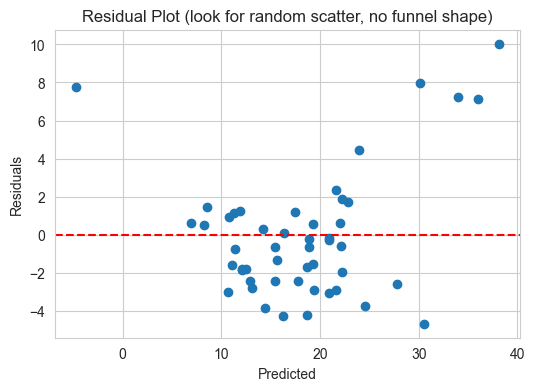

In [26]:
lr = LinearRegression().fit(X_train_scaled, y_train)
preds = lr.predict(X_test_scaled)
residuals = y_test - preds

# Residual plot -> should show random scatter around 0 (no pattern) if linearity holds
plt.figure(figsize=(6,4))
plt.scatter(preds, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted'); plt.ylabel('Residuals')
plt.title('Residual Plot (look for random scatter, no funnel shape)')
plt.show()

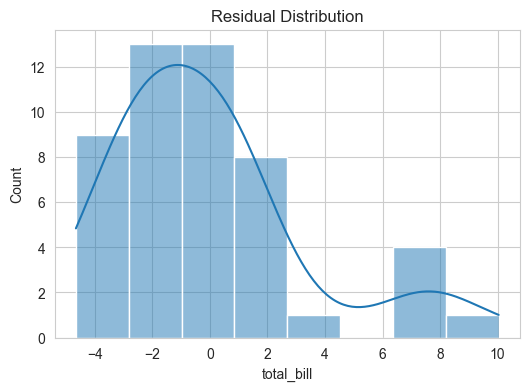

In [27]:
# Distribution of residuals -> should look roughly normal (bell-shaped)
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()

In [29]:
# Multicollinearity check using VIF (Variance Inflation Factor)
# Rule of thumb: VIF > 5-10 indicates problematic multicollinearity between features
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = X_train.copy()

# Convert boolean columns to integers
bool_cols = X_vif.select_dtypes(include='bool').columns
X_vif[bool_cols] = X_vif[bool_cols].astype(int)

# Convert remaining columns to numeric
X_vif = X_vif.apply(pd.to_numeric, errors='coerce')

# Remove invalid values
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [
        variance_inflation_factor(
            X_vif.to_numpy(dtype=float),
            i
        )
        for i in range(X_vif.shape[1])
    ]
})

vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

,feature,VIF
0,time_Dinner,28.404862
1,day_Sat,15.803404
2,day_Sun,14.127493
3,tip,10.094613
4,size,9.199223
5,tip_pct,6.993780
6,smoker_No,2.698740
7,day_Fri,2.501381
8,sex_Female,1.560975


## 10. Cross-Validation
**Why:** A single train-test split can be lucky/unlucky. K-Fold CV trains/tests the model K times on
different splits and averages the score -> a much more reliable performance estimate.

In [30]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in [('Linear Regression', LinearRegression()),
                     ('Ridge', Ridge()),
                     ('Random Forest', RandomForestRegressor(n_estimators=200, random_state=42))]:
    scores = cross_val_score(model, X_train_scaled if 'Forest' not in name else X_train, y_train, cv=kf, scoring='r2')
    cv_results[name] = scores
    print(f"{name}: mean R2 = {scores.mean():.3f}  (+/- {scores.std():.3f})")

Linear Regression: mean R2 = 0.660  (+/- 0.386)
Ridge: mean R2 = 0.674  (+/- 0.357)
Random Forest: mean R2 = 0.850  (+/- 0.060)


In [ ]:
# linear_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model', LinearRegression())
# ])

# ridge_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model', Ridge())
# ])

# models = [
#     ('Linear Regression', linear_pipeline),
#     ('Ridge', ridge_pipeline),
#     (
#         'Random Forest',
#         RandomForestRegressor(
#             n_estimators=200,
#             random_state=42
#         )
#     )
# ]

# for name, model in models:
#     scores = cross_val_score(
#         model,
#         X_train,
#         y_train,
#         cv=kf,
#         scoring='r2'
#     )

#     print(
#         f"{name}: mean R2 = {scores.mean():.3f} "
#         f"(+/- {scores.std():.3f})"
#     )

## 11. Hyperparameter Tuning
**Why:** Default model settings are rarely optimal. We search over combinations of hyperparameters to
find the best-performing configuration.

- **GridSearchCV**: exhaustively tries every combination — thorough but slow for large grids.
- **RandomizedSearchCV**: samples random combinations — faster, good when the search space is huge.


In [31]:
# GridSearchCV on Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params (GridSearchCV):", grid.best_params_)
print("Best CV R2:", grid.best_score_)

Best params (GridSearchCV): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R2: 0.8523041694809382


In [32]:
# RandomizedSearchCV on Gradient Boosting - faster for bigger search spaces
param_dist = {
    'n_estimators': [100, 150, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5]
}
rand_search = RandomizedSearchCV(GradientBoostingRegressor(random_state=42), param_dist,
                                  n_iter=8, cv=3, scoring='r2', random_state=42, n_jobs=-1)
rand_search.fit(X_train, y_train)
print("Best params (RandomizedSearchCV):", rand_search.best_params_)
print("Best CV R2:", rand_search.best_score_)

Best params (RandomizedSearchCV): {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2}
Best CV R2: 0.8949650935871061


## 12. Feature Importance & Selection
**Why:** Not all features contribute equally. Removing weak/noisy features can simplify the model,
speed up training, and sometimes improve accuracy.

- **Tree-based feature_importances_**: how much each feature reduces impurity across the forest.
- **RFE (Recursive Feature Elimination)**: repeatedly fits the model and removes the weakest feature.


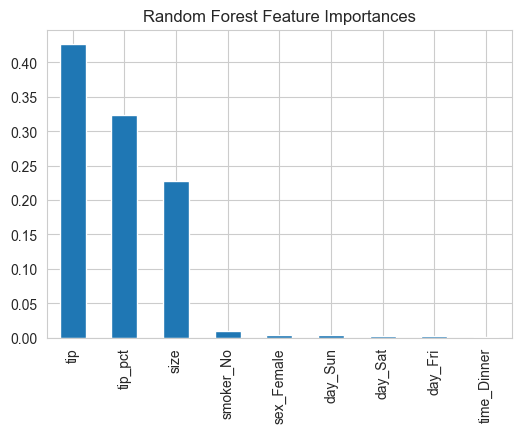

In [33]:
rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(6,4))
importances.plot(kind='bar')
plt.title('Random Forest Feature Importances')
plt.show()

In [34]:
# RFE with Linear Regression to select top 3 features
rfe = RFE(LinearRegression(), n_features_to_select=3)
rfe.fit(X_train_scaled, y_train)
selected = X_train.columns[rfe.support_]
print("Top 3 features selected by RFE:", list(selected))

Top 3 features selected by RFE: ['tip', 'tip_pct', 'smoker_No']


## 13. Learning Curves (Bias-Variance Tradeoff)
**Why:** Learning curves show train vs validation score as training size grows.
- Both scores low & close together -> **high bias / underfitting** (model too simple).
- Big gap between train (high) and validation (low) -> **high variance / overfitting** (model too complex).


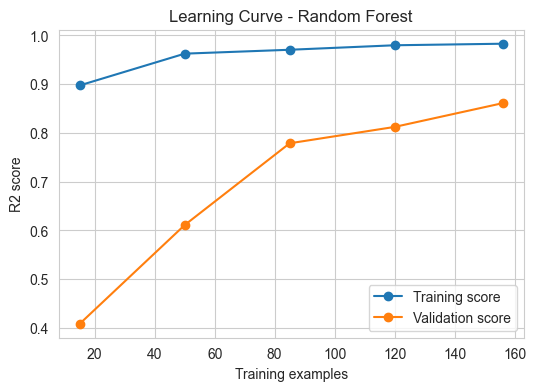

In [35]:
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=200, random_state=42), X_train, y_train, cv=5,
    scoring='r2', train_sizes=np.linspace(0.1, 1.0, 5))

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training score')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation score')
plt.xlabel('Training examples'); plt.ylabel('R2 score')
plt.title('Learning Curve - Random Forest')
plt.legend()
plt.show()

## 14. Pipeline (Preprocessing + Model in One Object)
**Why:** Pipelines chain preprocessing and modeling steps into a single object. This prevents data
leakage (transformations are correctly re-fit only on training folds during CV) and makes deployment
much simpler — one `.fit()` / `.predict()` call does everything.

In [36]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])
pipeline.fit(X_train, y_train)
print("Pipeline R2 on test set:", r2_score(y_test, pipeline.predict(X_test)))

Pipeline R2 on test set: 0.8921851913186357


## 15. Saving the Best Model (Deployment Prep)
**Why:** Once we're happy with a model, we persist it to disk with `joblib` so it can be loaded later
in a production app (e.g. Flask/Streamlit) without retraining.

In [37]:
import joblib

best_model = pipeline  # swap this for whichever model performed best in results_df
joblib.dump(best_model, 'best_regression_model.pkl')

# To reuse later in a deployment script:
# loaded_model = joblib.load('best_regression_model.pkl')
# loaded_model.predict(new_data)
print("Model saved as best_regression_model.pkl")

Model saved as best_regression_model.pkl


## 16. Final Model Comparison Table

In [38]:
results_df

,Model,MAE,MSE,RMSE,R2
0,Polynomial Regression (deg=2),1.362245,4.558881,2.135154,0.946232
1,Gradient Boosting Regressor,1.192788,4.765325,2.182963,0.943798
2,LightGBM Regressor,1.836632,6.655873,2.579898,0.921500
3,XGBoost Regressor,1.716703,8.349566,2.889562,0.901525
4,Random Forest Regressor,1.642603,9.135684,3.022529,0.892253
5,Linear Regression,2.468301,11.131759,3.336429,0.868712
6,Ridge Regression,2.480680,11.216533,3.349109,0.867712
7,Lasso Regression,2.461408,11.308181,3.362764,0.866631
8,ElasticNet,2.615138,12.396262,3.520833,0.853798
9,Decision Tree Regressor,4.567541,39.394987,6.276543,0.535374


## 17. Summary — Topics Covered in This Notebook
- EDA (info, describe, nulls, distributions, correlation heatmap, pairplot, boxplots)
- Feature engineering (imputation: mean/median/KNN, outlier capping via IQR, new feature creation)
- Encoding: LabelEncoder, OneHotEncoder/get_dummies, OrdinalEncoder
- Scaling: StandardScaler, MinMaxScaler, RobustScaler
- Train-test split (with correct order to avoid data leakage)
- Regression models: Linear, Ridge, Lasso, ElasticNet, Polynomial, Decision Tree, Random Forest,
  Gradient Boosting, XGBoost, LightGBM, SVR, KNN Regressor
- Linear regression assumption checks: residual plots, normality, VIF (multicollinearity)
- Cross-validation (KFold)
- Hyperparameter tuning: GridSearchCV, RandomizedSearchCV
- Feature importance & selection (tree importances, RFE)
- Learning curves / bias-variance tradeoff
- Pipelines
- Model persistence with joblib

**Next notebook:** `02_Supervised_Classification.ipynb`
